**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 6**
Ingeniería de características (FE)

---

*   NOMBRE: Adrian Valdes Zavala
*   MATRÍCULA: A01720439

En esta actividad trabajarás con el archivo `computer_prices.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de computadoras portátiles y de escritorio, disponible en Kaggle.

Los datos fueron recopilados para analizar el rendimiento y el precio de los dispositivos, e incluyen información sobre hardware, almacenamiento, conectividad y otras especificaciones técnicas. Los indicadores incluidos son:

* `device_type`: Tipo de dispositivo (ej. laptop, desktop)
* `brand`: Marca del dispositivo
* `model`: Modelo del dispositivo
* `release_year`: Año de lanzamiento del dispositivo
* `os`: Sistema operativo instalado
* `form_factor`: Factor de forma o diseño del dispositivo (ej. laptop, ultrabook, desktop tower)
* `cpu_brand`: Marca del procesador
* `cpu_tier`: Nivel o gama del procesador, ordinal del 1 al 6 según desempeño
* `cpu_cores`: Número de núcleos del procesador
* `cpu_threads`: Número de hilos de ejecución del procesador
* `gpu_brand`: Marca de la tarjeta gráfica
* `gpu_model`: Modelo específico de la tarjeta gráfica
* `gpu_tier`: Nivel o gama de la GPU, ordinal del 1 al 6 según desempeño
* `vram_gb`: Memoria de video de la GPU en gigabytes
* `ram_gb`: Memoria RAM del dispositivo en gigabytes
* `storage_type`: Tipo de almacenamiento (ej. HDD, SSD)
* `storage_gb`: Capacidad de almacenamiento en gigabytes
* `storage_drive_count`: Número de unidades de almacenamiento instaladas
* `display_type`: Tipo de pantalla (ej. IPS, TN, OLED)
* `charger_watts`: Potencia del cargador (en watts) para laptops
* `psu_watts`: Potencia de la fuente de poder (en watts) para desktops
* `wifi`: Estándar de conectividad Wi-Fi (ej. Wi-Fi 5, 6, 6E, 7)
* `bluetooth`: Versión de Bluetooth
* `weight_kg`: Peso del dispositivo en kilogramos
* `warranty_months`: Meses de garantía del dispositivo
* `price`: Precio del dispositivo. Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [3]:
# Instalar las bibliotecas necesarias
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
from scipy.stats import probplot
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer, PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders.binary import BinaryEncoder
from scipy.stats import boxcox, skew


1. Descarga el archivo: `computer_prices.csv` y guarda, en un dataframe (`compu_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.
* Elimina las variables:
  * `model`: Debido a su altísima cardinalidad, lo que dificulta su uso en análisis y modelado.
  * `cpu_model`: Además de su elevada cardinalidad, su información ya está representada de manera implícita en otras variables como: `cpu_tier`, `cpu_cores` y `cpu_threads`

In [36]:
print("15 son Numeros / 12 son Textos")
print()
compu_df = pd.read_csv("/content/drive/MyDrive/MaestriaMNA/Ciencia de Datos/computer_prices.csv")
print(compu_df.info())
print(compu_df.nunique())
compu_df = compu_df.drop(columns=["model", "cpu_model"])

15 son Numeros / 12 son Textos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 27 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  gpu_brand            100000 non-null  object 
 12  gpu_model            100000 non-null  object 
 13  gpu_tier             100000 non-null  int64  
 14  vram_gb              100000 non-null 

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados y/o faltantes.
* Obtén las estadísticas descriptivas, separado las numéricas y las categóricas. De estas últimas incluye las tablas de frecuencia.
* Genera histogramas para las numéricas y diagramas de barras para las categóricas. Con alta cardinalidad, sólo incluye los 10 valores más frecuentes.

No hay valores NaN ni Duplicados

Duplicados: 0

device_type            0
brand                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64
Tabla de frequencia:

device_type
Laptop     59844
Desktop    40156
Name: count, dtype: int64


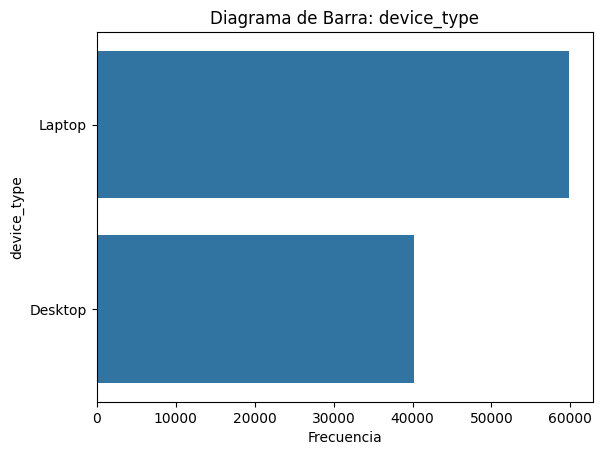

Tabla de frequencia:

brand
Lenovo      15992
HP          14114
Dell        14005
Apple       11915
ASUS        10159
Acer         9925
Samsung      8066
MSI          7891
Gigabyte     4900
Razer        3033
Name: count, dtype: int64


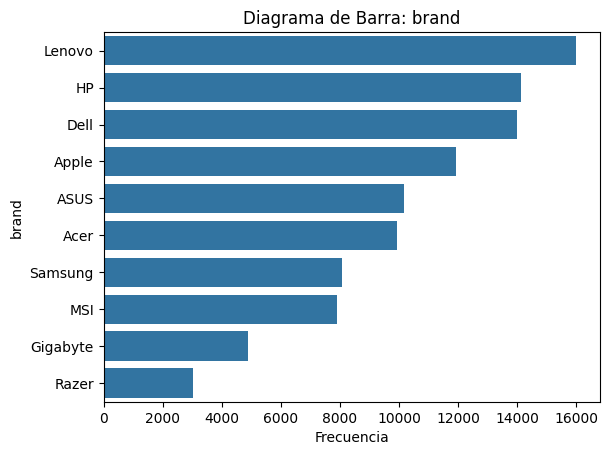

Tabla de frequencia:

os
Windows     71817
macOS       18207
Linux        6109
ChromeOS     3867
Name: count, dtype: int64


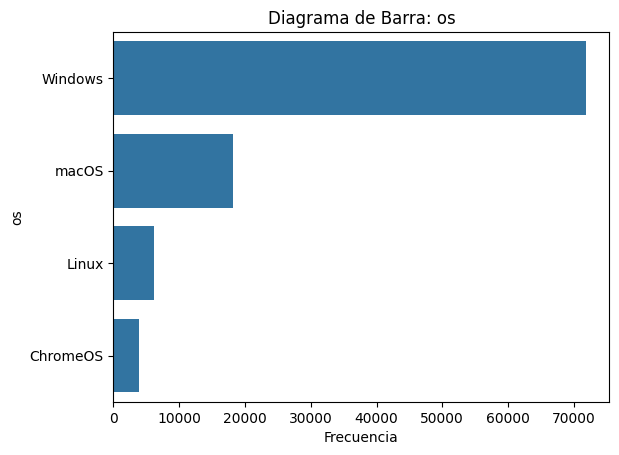

Tabla de frequencia:

form_factor
Mainstream     17819
Gaming         16876
ATX            15597
Ultrabook      13236
Micro-ATX       8672
Full-Tower      7110
2-in-1          7049
SFF             5585
Workstation     4864
Mini-ITX        3192
Name: count, dtype: int64


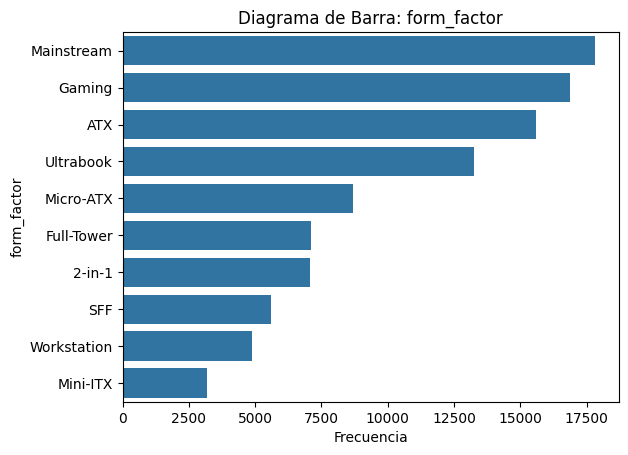

Tabla de frequencia:

cpu_brand
Intel    52774
AMD      35311
Apple    11915
Name: count, dtype: int64


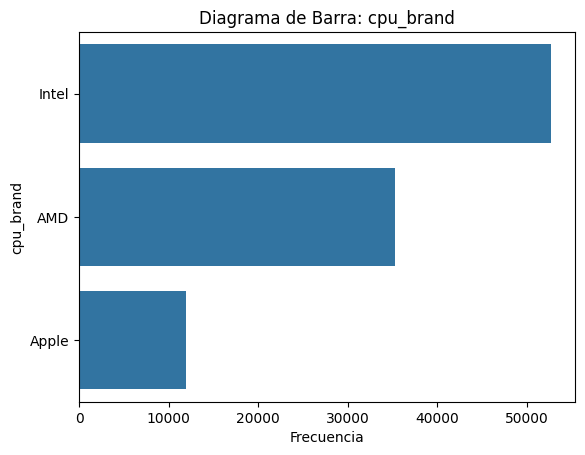

Tabla de frequencia:

gpu_brand
NVIDIA    54712
Apple     18922
AMD       15767
Intel     10599
Name: count, dtype: int64


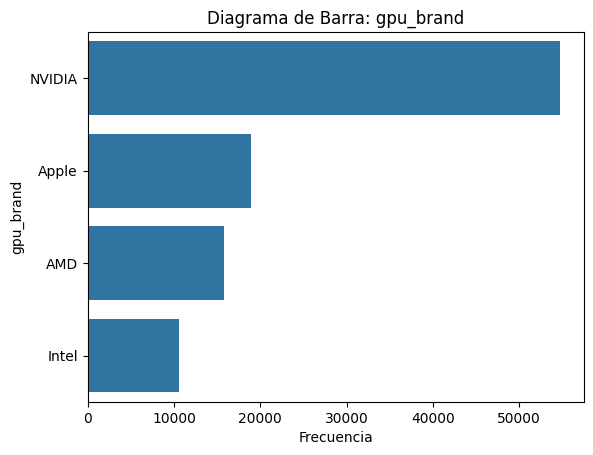

Tabla de frequencia:

gpu_model
Apple Integrated    18922
RTX 40 70            5743
RTX 30 70            5692
RTX 40 60            5437
RTX 30 60            5314
RTX 30 50            5046
RTX 40 50            4970
RTX 40 80            4676
RTX 30 80            4618
RTX 30 80 Ti         2752
RTX 40 80 Ti         2685
Arc A580             1947
Arc A310             1818
Arc A380             1817
RX 7000 70           1636
RX 6000 70           1620
Arc A700             1611
RX 6000 60           1608
RX 7000 60           1521
RX 7000 50           1404
RX 6000 50           1375
RX 7000 80           1349
RTX 20 70            1319
RX 6000 80           1293
RTX 20 60            1229
RTX 40 90            1137
RTX 30 90            1129
RTX 20 50            1120
RTX 20 80            1009
Arc A770              922
RX 6000 80 XT         823
RX 7000 80 XT         814
RTX 20 80 Ti          571
Arc B580              475
Arc B380              474
Arc B310              429
Arc A770 Limited      387
Arc B7

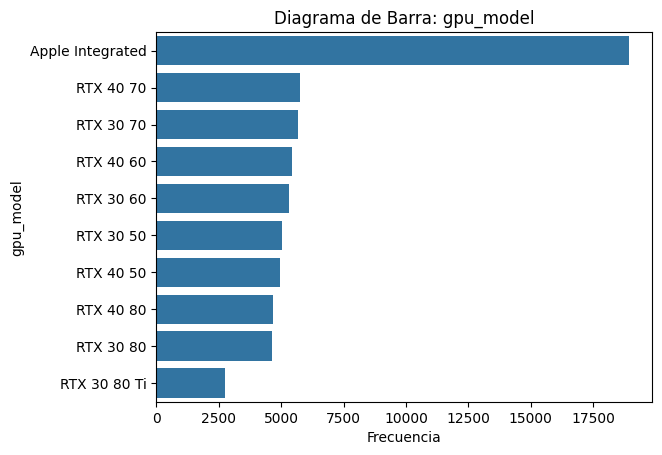

Tabla de frequencia:

storage_type
NVMe      45059
SSD       24937
HDD       15023
Hybrid    14981
Name: count, dtype: int64


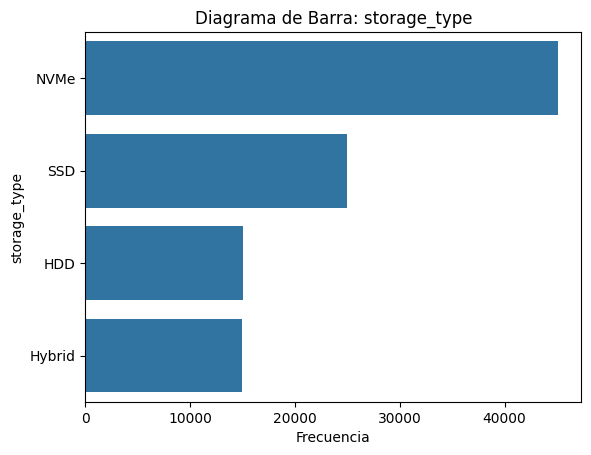

Tabla de frequencia:

display_type
LED         32000
OLED        21910
IPS         17742
Mini-LED    12188
QLED        10069
VA           6091
Name: count, dtype: int64


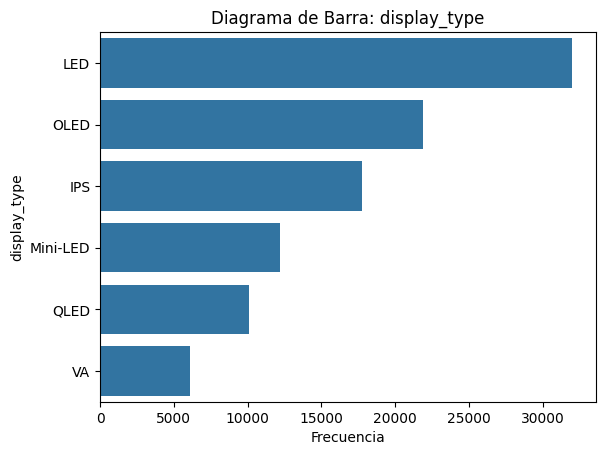

Tabla de frequencia:

wifi
Wi-Fi 6     46149
Wi-Fi 6E    25923
Wi-Fi 5     19926
Wi-Fi 7      8002
Name: count, dtype: int64


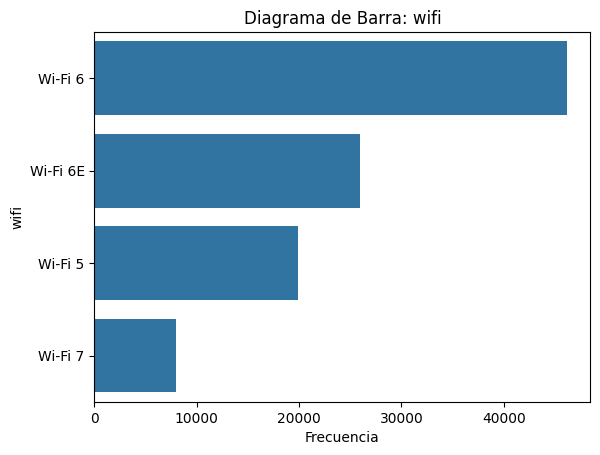

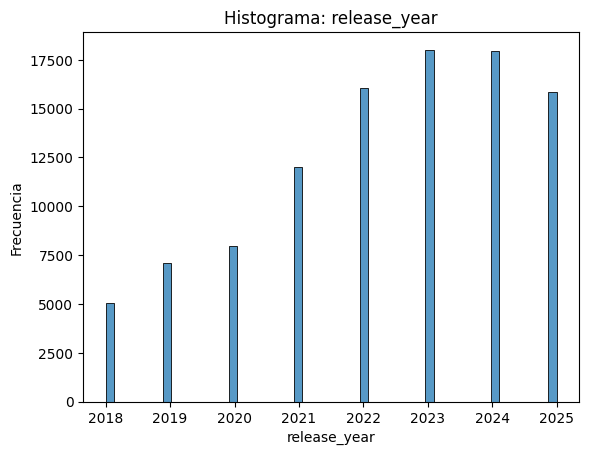

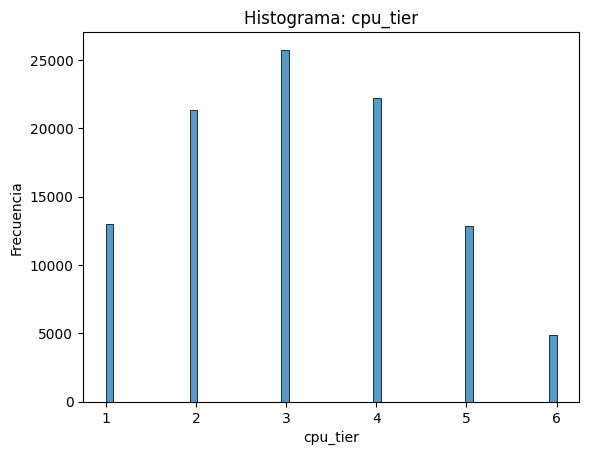

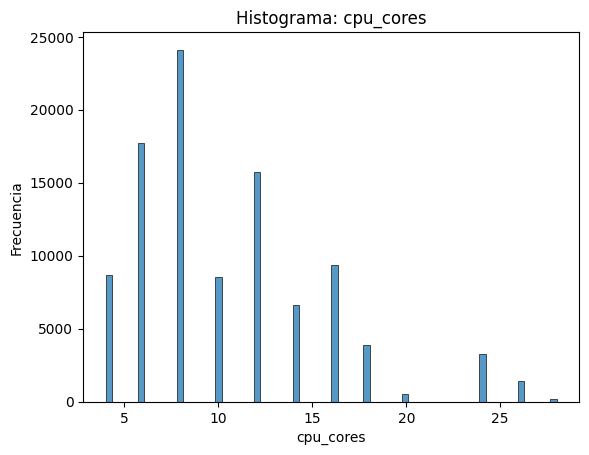

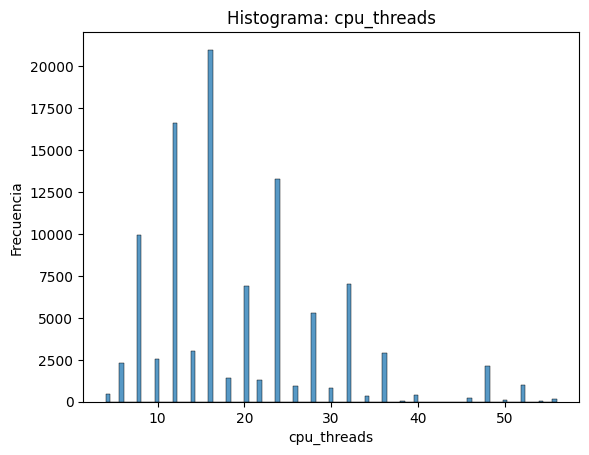

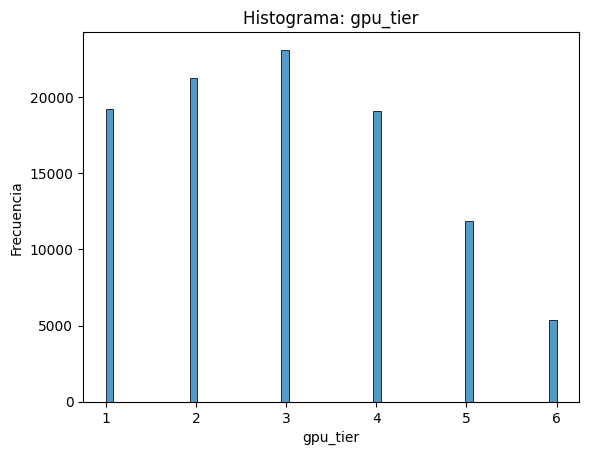

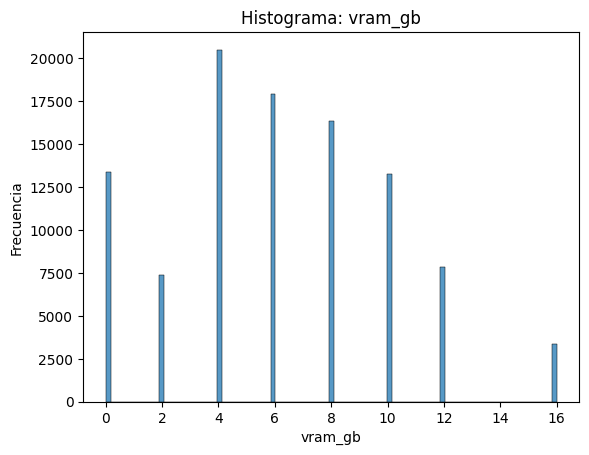

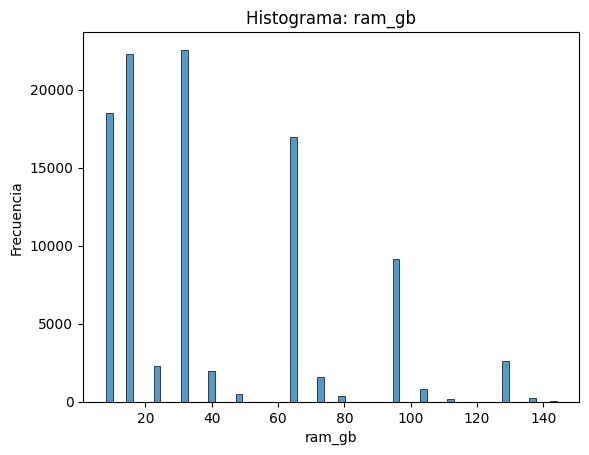

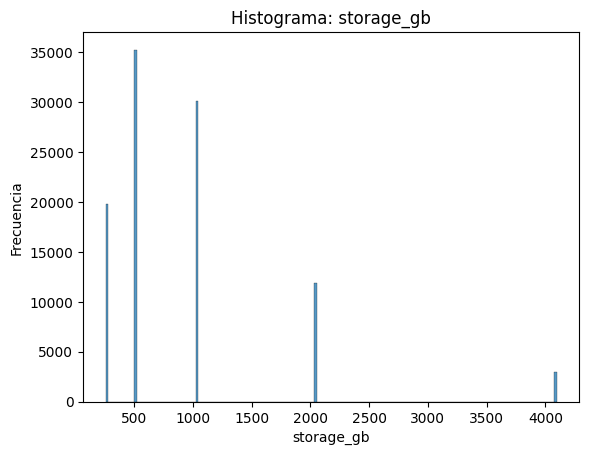

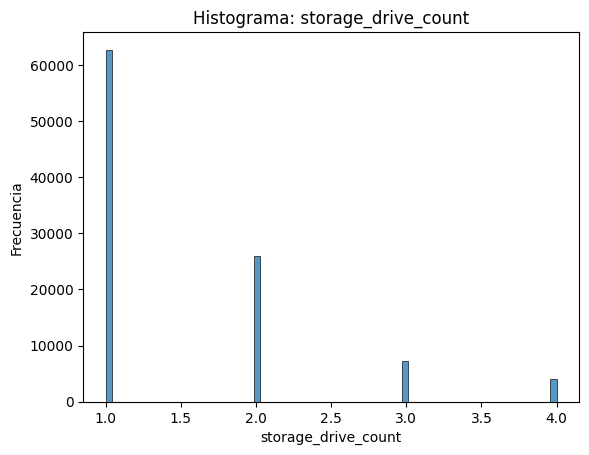

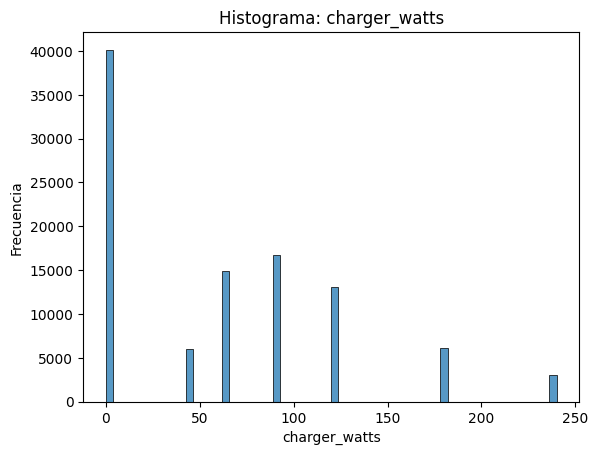

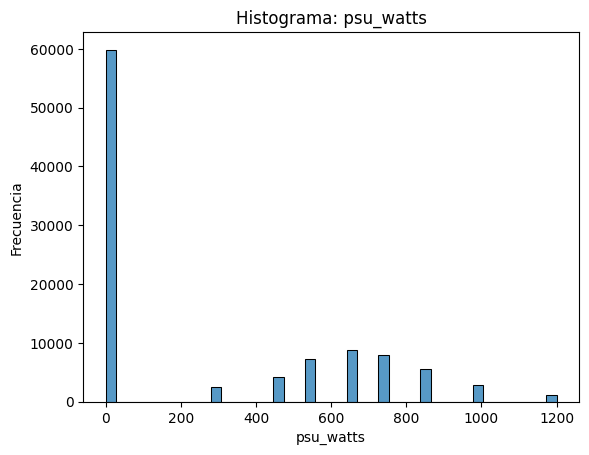

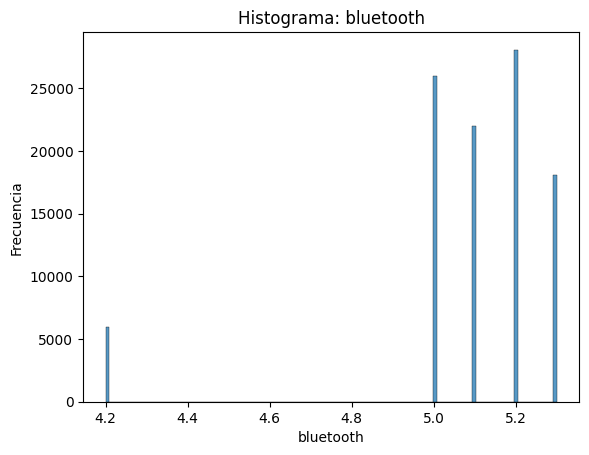

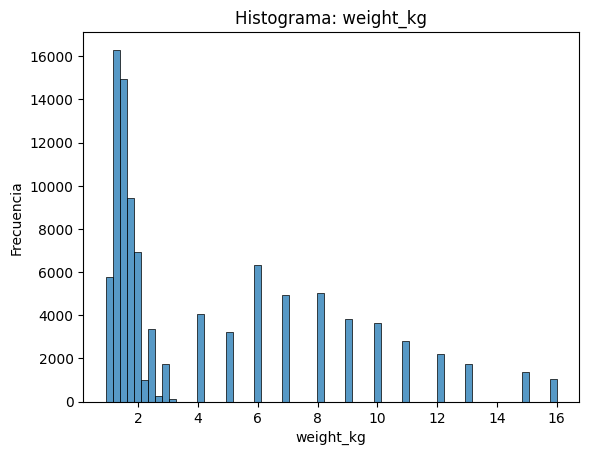

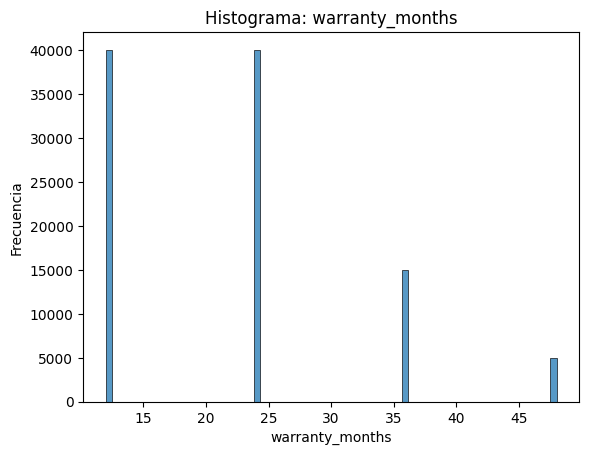

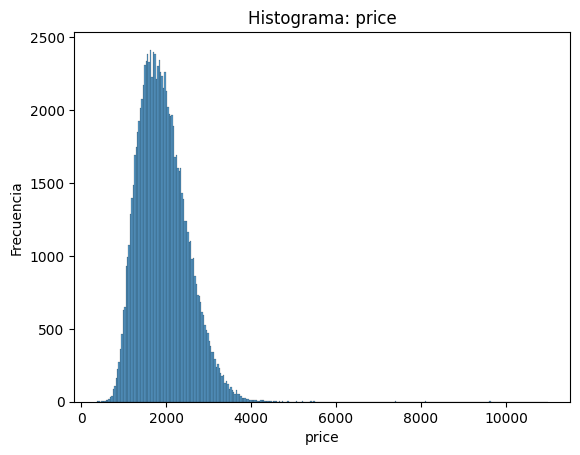

In [37]:
print("No hay valores NaN ni Duplicados")
print()
print(f'Duplicados: {compu_df.duplicated().sum()}')
print()
print(compu_df.isna().sum())

num_cols = compu_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = compu_df.select_dtypes(include=['object']).columns
stats_numericas = compu_df[num_cols].describe().T
stats_categoricas = compu_df[cat_cols].describe().T

for col in cat_cols:
  print("Tabla de frequencia:")
  print()
  freq = compu_df[col].value_counts()
  print(freq)
  if len(freq) > 10:
      freq = freq.head(10)

  sns.barplot(x=freq.values, y=freq.index)
  plt.title(f"Diagrama de Barra: {col}")
  plt.xlabel("Frecuencia")
  plt.ylabel(col)
  plt.show()

for col in num_cols:
    sns.histplot(compu_df[col])
    plt.title(f"Histograma: {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()








3. Dibuja un mapa de calor con la matriz de correlación para las variables numéricas del conjunto de datos.
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos.
* Reflexiona sobre cuáles variables representan de manera general la capacidad del hardware y mantenlas; elimina las demás por aportar información redundante.
* Incluye una breve justificación de tus decisiones.

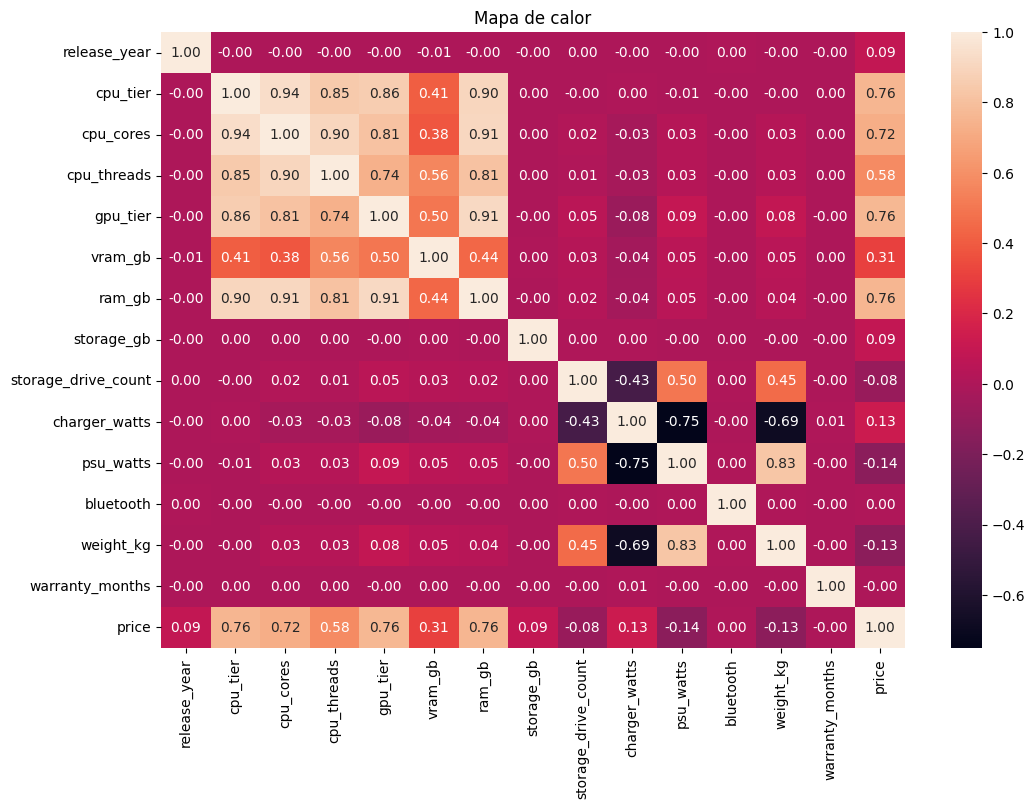

cpu_tier   cpu_cores    0.937376
cpu_cores  cpu_tier     0.937376
           ram_gb       0.906770
gpu_tier   ram_gb       0.912918
ram_gb     cpu_cores    0.906770
           gpu_tier     0.912918
dtype: float64

Variables que consideramos que representa la capacidad del hardware:
CPU_tier, CPU_cores, CPU_Threads, GPU_Tier, Vram_GB, Ram_GB, Storage_GB, release_year, price
De las mencionadas anteriores, considero que release year y storage drive count deberian estar mas
relacionados con el desempeño general del dispositivo, sin embargo en el mapa de calor, no hay gran
relevancia entre esas 2, pero dado a que en la siguiente pregunta se pide analizar los años de lanzamiento
Decidimos dejar Release_year. El resto de los componentes seleccionados ademas de tener alta coorelacion son componentes indispensables para el desempeño de 
una computadora, y suelen estar ligados a un precia mas alto conforme la capacidad.

Update:
Al avanzar con el ejercicio vemos que solicitan charger y psu watts

In [38]:
num_cols = compu_df.select_dtypes(include=['int64', 'float64'])
correlacion = num_cols.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlacion, annot=True, fmt=".2f")
plt.title("Mapa de calor")
plt.show()

long_corr = correlacion.stack()
high_corr = long_corr[(long_corr > 0.9) & (long_corr < 1)]

print(high_corr)
print()
print("Variables que consideramos que representa la capacidad del hardware:")
print("CPU_tier, CPU_cores, CPU_Threads, GPU_Tier, Vram_GB, Ram_GB, Storage_GB, release_year, price")
print("De las mencionadas anteriores, considero que release year y storage drive count deberian estar mas")
print("relacionados con el desempeño general del dispositivo, sin embargo en el mapa de calor, no hay gran")
print("relevancia entre esas 2, pero dado a que en la siguiente pregunta se pide analizar los años de lanzamiento")
print("Decidimos dejar Release_year. El resto de los componentes seleccionados ademas de tener alta coorelacion son componentes indispensables para el desempeño de ")
print("una computadora, y suelen estar ligados a un precia mas alto conforme la capacidad.")
print()

print("Update:")
print("Al avanzar con el ejercicio vemos que solicitan charger y psu watts, los cuales originalmente habiamos borrado.")
print("Viendo el mapa mas a detalle, vemos que si tiene relacion con algunos otros componentes, aunque es muy pequeña.")
print("Sin embargo, habiendo dicho eso, las regresamos al dataframe (es decir no las borramos)")

print("Update 2:")
print("Mismo caso que el anterior, con weight_kg cunado vimos que esta variable fue solicitada en otra pregunta")
print("Volvimos a analizar y a pesar de no tener coorelaciones tan fuertes, tiene la suficiente para ser incluida")
print("la regresamos al dataframe (es decir no la borramos)")

compu_df = compu_df.drop(columns=[
    'warranty_months',
    'bluetooth',
    'storage_drive_count',
])
num_cols = compu_df.select_dtypes(include=['int64', 'float64'])




4. Para comenzar con la ingeniería de características, crea una copia del dataframe y asígnala a un nuevo objeto llamado `compu_trans`.
* Calcula cuántos años han pasado desde el lanzamiento de cada computadora y almacénalo en una nueva columna llamada `years_since_release`; luego, elimina la columna original.
* Utiliza `KBinsDiscretizer` para reemplazar la columna `vram_gb` en 4 bins ordinales basados en cuantiles.
* Imprime los valores que delimitan cada bin y haz un histograma para ver la cantidad de observaciones en cada uno, con el fin de entender cómo se agruparon los datos.

En la tabla podemos ver como el grupo 3, es decir, alto vram es el mas común.
[ 0.  4.  6.  8. 16.]



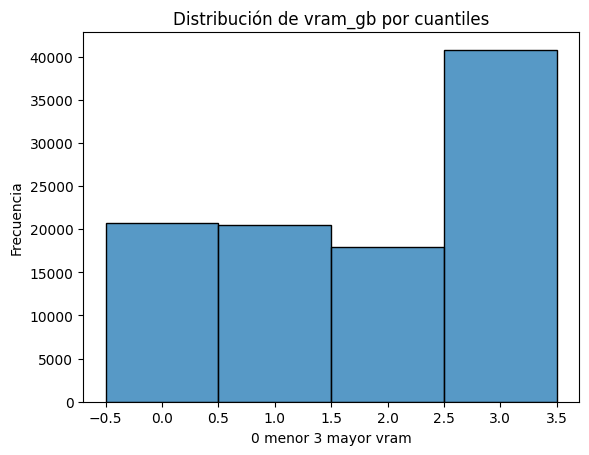

In [39]:
compu_trans = compu_df.copy()
compu_trans['years_since_release'] = date.today().year - compu_trans['release_year']
compu_trans = compu_trans.drop(columns=['release_year'])
kbins = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
compu_trans['vram_gb'] = kbins.fit_transform(compu_trans[['vram_gb']])
print("En la tabla podemos ver como el grupo 3, es decir, alto vram es el mas común.")
print(kbins.bin_edges_[0])
print()

sns.histplot(compu_trans['vram_gb'], bins=4, discrete=True)
plt.title("Distribución de vram_gb por cuantiles")
plt.xlabel("0 menor 3 mayor vram")
plt.ylabel("Frecuencia")
plt.show()






5. Observa los histogramas del ejercicio 2. Notarás que en las variables `charger_watts` y `psu_watts` aparece una barra en 0. Analiza por qué ocurre esto y qué significa en relación con el tipo de dispositivo.
* Como estas variables son mutuamente excluyentes, combínalas en una nueva columna llamada `power_watts` que contenga la potencia correspondiente de cada dispositivo y, a continuación, haz un histograma para verificar que la distribución resultante es bimodal.
* Por último, borra las columnas originales `charger_watts` y `psu_watts`.

Despues de ver que cuando charger_watts es 0, psu_watts nunca es 0 y viceverza
Nos hace pensar que charger son para dispositivos moviles, en este caso Laptops.
Mientras que para PSU, son para PC's, Desktops. Que no cuentan con pila recargable.



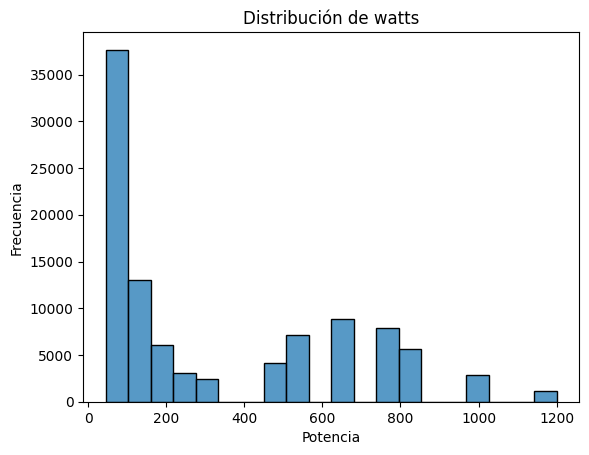

In [40]:
print("Despues de ver que cuando charger_watts es 0, psu_watts nunca es 0 y viceverza")
print("Nos hace pensar que charger son para dispositivos moviles, en este caso Laptops.")
print("Mientras que para PSU, son para PC's, Desktops. Que no cuentan con pila recargable.")
print()
compu_trans['power_watts'] = compu_trans[['charger_watts', 'psu_watts']].max(axis=1)
compu_trans = compu_trans.drop(columns=['charger_watts', 'psu_watts'])
sns.histplot(compu_trans['power_watts'], bins=20)
plt.title("Distribución de watts")
plt.xlabel("Potencia")
plt.ylabel("Frecuencia")
plt.show()



6. Para disminuir el sesgo de la variable `price`, crea tres transformadores: logaritmo, raíz cuadrada y Box - Cox.
* Aplica cada transformador a la variable price, dejando el resultado en variables temporales. El objetivo es comparar los efectos de cada transformación antes de decidir cuál aplicar de manera definitiva sobre las variables continuas del dataframe.
* De la variable original y de cada una de las tres transformaciones se debe mostrar:
  * Histograma: para observar la distribución de los datos.
  * Boxplot: para identificar posibles valores atípicos.
  * Q-Q plot: para evaluar la normalidad de la variable.
  * Skew (sesgo): para cuantificar la asimetría de la distribución.
  * Cantidad de outliers: para conocer cuántos valores extremos existen.
* En función de los resultados obtenidos al comparar las transformaciones, decide cuál logró el mejor efecto sobre la distribución de la variable y aplícala directamente en el dataframe, reemplazando las variables continuas: `weight_kg`, `power_watts` y `price`.

Con base a los resultados obtenidos, consideramos que BoxCox es la mejor opcion
Podemos ver que las 3 transformaciones disminuyen los outliers
Sin embargo a pesar de que algunas de las graficas, especialmente Log y Boxcox se ven similares
Con los resultados de outliers y skew podemos tomar boxcox como la mejor opcion.

===== Original =====
Skew -  0.9866291457617555
Cantidad de outliers: 976


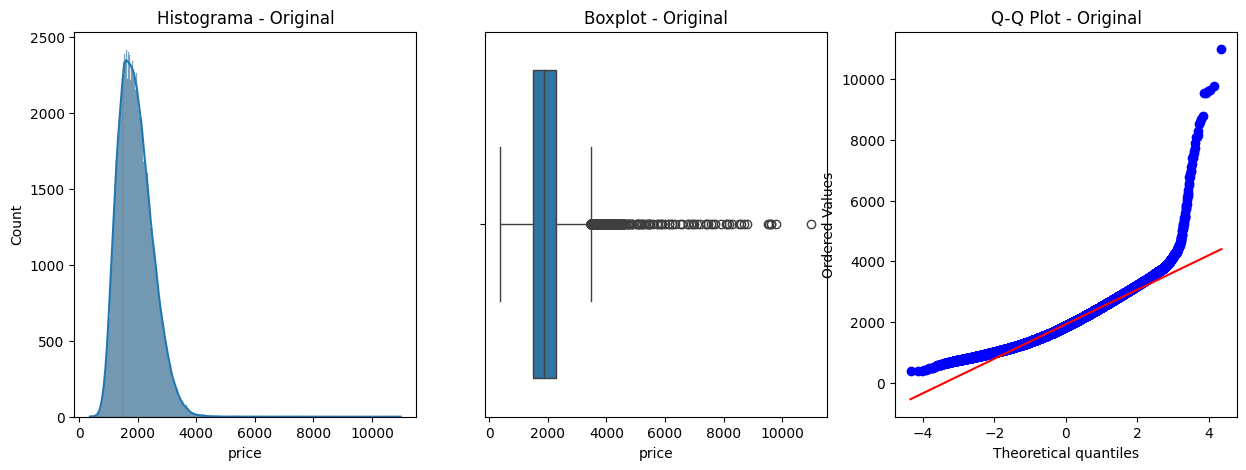


===== Log =====
Skew -  -0.13310304717875493
Cantidad de outliers: 386


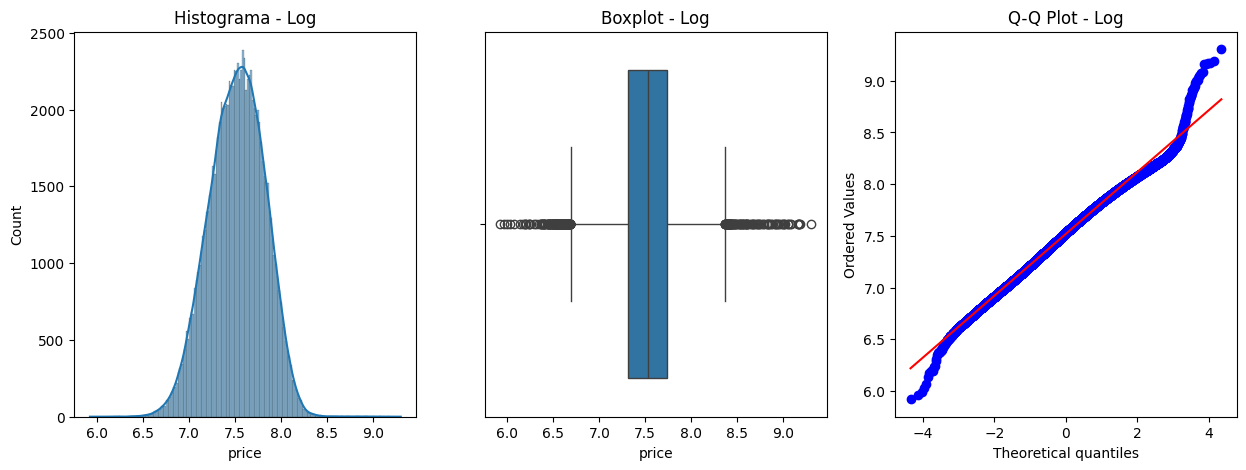


===== Sqrt =====
Skew -  0.3322478296859819
Cantidad de outliers: 364


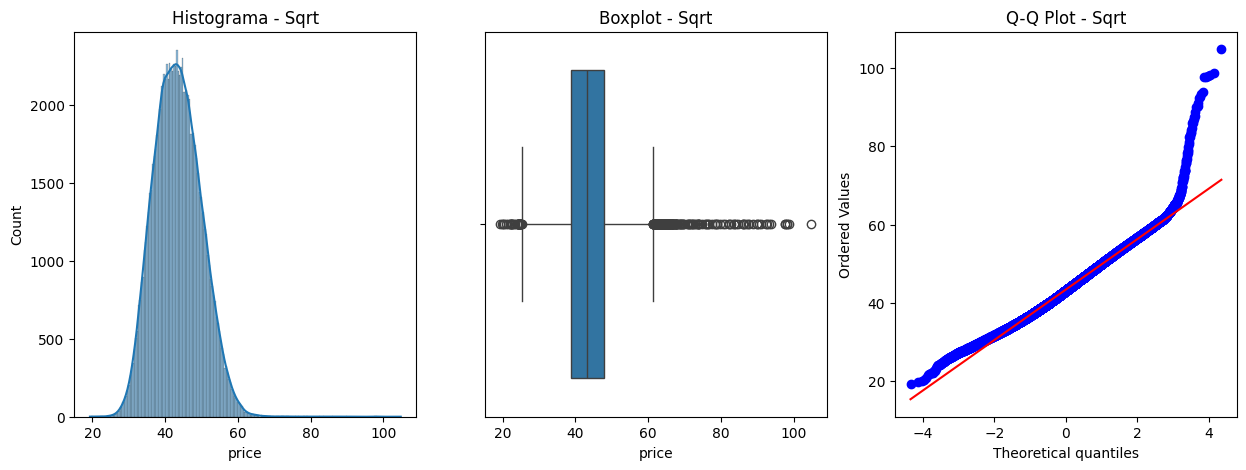


===== Boxcox =====
Skew -  -0.00023827064005421808
Cantidad de outliers: 317


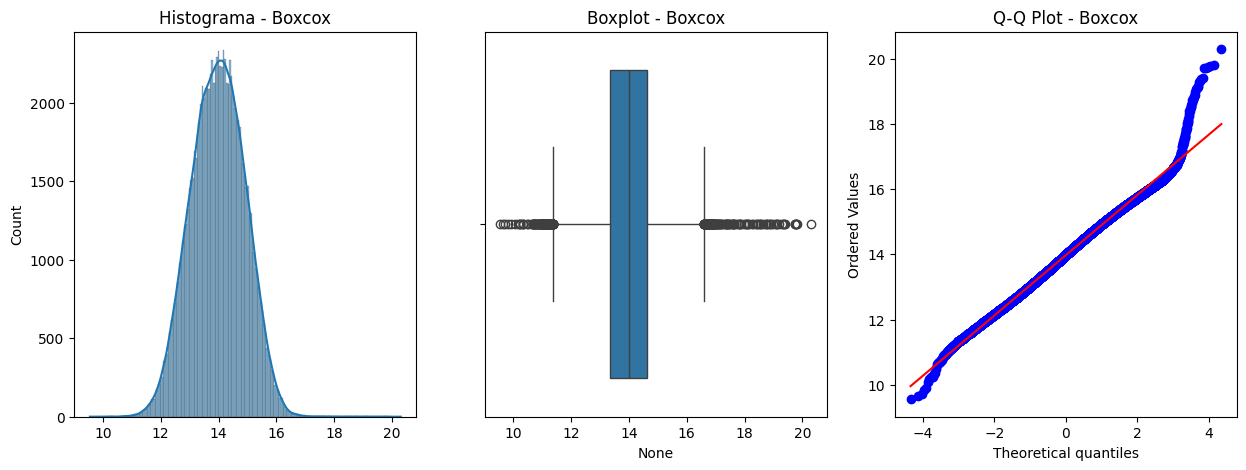

Variable actualcon Box–Cox: weight_kg, lambda = -0.4804237131299049
Variable actualcon Box–Cox: power_watts, lambda = -0.16503256776233965
Variable actualcon Box–Cox: price, lambda = 0.15041805793433355


In [41]:
print("Con base a los resultados obtenidos, consideramos que BoxCox es la mejor opcion")
print("Podemos ver que las 3 transformaciones disminuyen los outliers")
print("Sin embargo a pesar de que algunas de las graficas, especialmente Log y Boxcox se ven similares")
print("Con los resultados de outliers y skew podemos tomar boxcox como la mejor opcion.")

original = compu_trans['price']
price_log = np.log(compu_trans['price'])
price_sqrt = np.sqrt(compu_trans['price'])
price_boxcox, lambda_boxcox = boxcox(compu_trans['price'])
price_boxcox = pd.Series(price_boxcox, index=compu_trans.index)
lista_transformaciones = [original, price_log, price_sqrt, price_boxcox]

def Cantidad_de_Outliers(transformacion):
    # Cantidad de outliers
    Q1 = transformacion.quantile(0.25)
    Q3 = transformacion.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return ((transformacion < lower) | (transformacion > upper)).sum()

cont = 0
names = ["Original", "Log", "Sqrt", "Boxcox"]
for transformacion in lista_transformaciones:
    # Skew
    print(f"\n===== {names[cont]} =====")
    print("Skew - ", skew(transformacion))
    print("Cantidad de outliers:", Cantidad_de_Outliers(transformacion))

    plt.figure(figsize=(15,5))

    # Histograma
    plt.subplot(1,3,1)
    sns.histplot(transformacion, kde=True)
    plt.title(f"Histograma - {names[cont]}")

    # Boxplot
    plt.subplot(1,3,2)
    sns.boxplot(x=transformacion)
    plt.title(f"Boxplot - {names[cont]}")

    # Q-Q plot
    plt.subplot(1,3,3)
    probplot(transformacion, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot - {names[cont]}")
    plt.show()
    cont += 1

vars_continuas = ['weight_kg', 'power_watts', 'price']
for var in vars_continuas:
    transformed, lambda_bc = boxcox(compu_trans[var])
    compu_trans[var] = pd.Series(transformed, index=compu_trans.index)
    print(f"Variable actualcon Box–Cox: {var}, lambda = {lambda_bc}")




7. Para que todas las variables numéricas estén en la misma escala, aplica `MinMaxScaler` de sklearn a todas las columnas numéricas del dataframe, reemplazando las columnas originales.

In [42]:
num_cols = compu_trans.select_dtypes(include=['int64', 'float64']).columns
print(compu_trans[num_cols].head(5))
compu_trans[num_cols] = MinMaxScaler().fit_transform(compu_trans[num_cols])
print(compu_trans[num_cols].head(5))


   cpu_tier  cpu_cores  cpu_threads  gpu_tier  vram_gb  ram_gb  storage_gb  \
0         3         12           24         2      2.0      16        1024   
1         4         12           24         4      3.0      64         512   
2         2          8           16         1      1.0       8         512   
3         2          6           12         2      2.0      16         512   
4         5         16           32         5      3.0      96         256   

   weight_kg      price  years_since_release  power_watts  
0   1.423738  13.084409                    4     4.027280  
1   0.600182  14.616126                    4     3.309631  
2   1.264217  14.014803                    2     4.068825  
3   1.201393  12.971066                    2     3.978717  
4   0.368418  15.149121                    2     3.175932  
   cpu_tier  cpu_cores  cpu_threads  gpu_tier   vram_gb    ram_gb  storage_gb  \
0       0.4   0.333333     0.384615       0.2  0.666667  0.058824    0.200000   
1       0

8. Aunque `wifi` es una variable categórica, sus categorías tienen un orden natural (Wi-Fi 5 < Wi-Fi 6 < Wi-Fi 6E < Wi-Fi 7). Codifícala usando `OrdinalEncoder`.
* Luego, escala la variable codificada entre 0 y 1 con `MinMaxScaler`, para que quede en la misma escala que las variables numéricas del dataframe.

Nota: Ambos cambios deben efectuarse sobre la columna original, de manera que quede una única columna `wifi` con toda la información transformada.

9. La variable `gpu_model` tiene muchas categorías. Usar *One-Hot Encoding* aumentaría significativamente la dimensionalidad del dataframe. Por ello, utiliza `BinaryEncoder` para codificarla.
* Guarda el resultado en un dataframe llamado `bin_df`. Más adelante, lo combinarás con `compu_transf` para integrar las variables codificadas.

10. Usa `OneHotEncoder` para codificar las variables categóricas restantes. Asegúrate de usar `drop='first'` para evitar la multicolinealidad y guarda el resultado en un dataframe llamado `ohe_df`
* Combina el dataframe `compu_transf` con las variables categóricas que fueron codificadas en `bin_df` y `ohe_df`. No olvides eliminar las variables originales.
* Usa `describe()` sobre el dataframe resultante para corroborar que todas las columnas estén escaladas entre 0 y 1 y que no queden variables categóricas sin codificar.